In [1]:
import torch
device = "cpu"
from torch import nn
import matplotlib.pyplot as plt

In [2]:
testing=torch.tensor([[1,2,2],
                      [2,4,5]],dtype=torch.float).to(device)
# testing
another_test = torch.randn_like(testing)
another_test

tensor([[-1.3187,  1.0972, -1.2305],
        [-0.0653, -0.0770, -0.2330]])

Problem 1 — Recover the hidden line
Goal

Train a model to discover an unknown linear relationship.

Data generation
x ∈ [-2 , 2]
y = 1.8x − 0.7

Add small noise.

noise ~ N(0 , 0.1)

So the real data becomes:

y = 1.8x − 0.7 + noise

Tasks

Generate the dataset.

Split 80/20 train/test.

Train a model to learn the relationship.

Plot:

training points

test points

predictions

Compute:

MAE

MSE

R²

What you should discover

Your model should learn approximately:

y ≈ 1.8x − 0.7

In [3]:

# Generate the dataset.
# x ∈ [-2 , 2]
x=torch.arange(-2,2,0.01).unsqueeze(dim=1)
# noise ~ N(0 , 0.1)
noise = torch.randn_like(x) * 0.1

# y = 1.8x − 0.7 + noise
y=1.8*x -0.7 + noise

# Split 80/20 train/test.
splits = int(0.8 * len(y))
train_sample,test_sample = y[:splits],y[splits:]
train_predict,test_predict = y[:splits],y[splits:]
train_sample,test_sample, train_predict,test_predict = train_sample.to(device),test_sample.to(device), train_predict.to(device),test_predict.to(device)



In [4]:
class LinearModel2(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=1, out_features=8),
        nn.Linear(in_features=8, out_features=16),
        nn.Linear(in_features=16, out_features=8),
        nn.Linear(in_features=8, out_features=1)
    )
  def forward(self,x:torch.tensor):
    return self.layer1(x)

In [5]:
model = LinearModel2()

In [6]:
loss = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.01)

In [7]:
# train for loss opt zero lobos

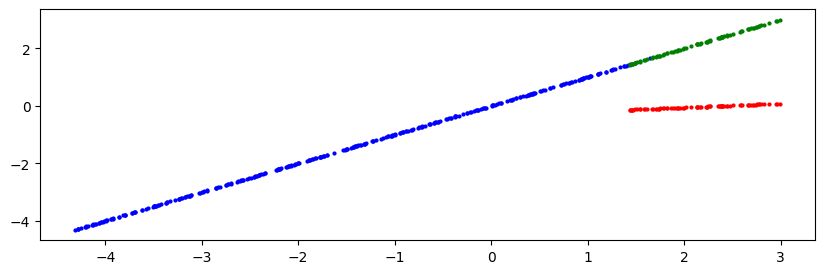

In [8]:
model.eval()
with torch.inference_mode():
  my_prediction = model(test_sample)

plt.figure(figsize=(10,3))
plt.scatter(train_sample,train_predict,s=4,c="b")
plt.scatter(test_sample,test_predict,s=4,c="g")
plt.scatter(test_sample,my_prediction,s=4,c="r")

In [12]:
# Train a model to learn the relationship.
epoch = 1000

for i in range(epoch):
  model.train()
  logit = model(train_sample)
  losses = loss(logit,train_predict)
  optimizer.zero_grad()
  losses.backward()
  optimizer.step()


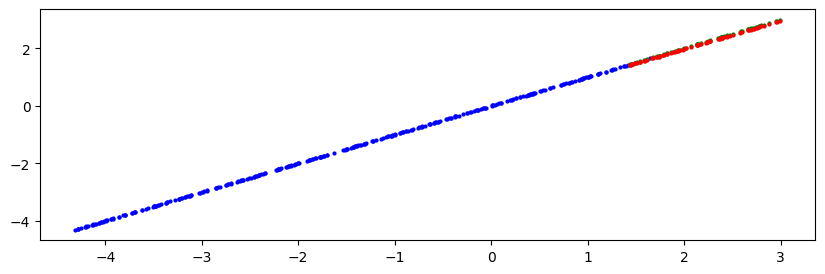

In [13]:
model.eval()
with torch.inference_mode():
  my_prediction = model(test_sample)

# Plot:
# training points
# test points
# predictions

plt.figure(figsize=(10,3))
plt.scatter(train_sample,train_predict,s=4,c="b")
plt.scatter(test_sample,test_predict,s=4,c="g")
plt.scatter(test_sample,my_prediction,s=4,c="r")


In [14]:
# Mean absolute error
mae = torch.abs(torch.mean(test_predict - my_prediction)).item()
mae

0.029268521815538406

In [16]:
# MSE (Mean Squared Error)

# MSE = (1/n) * sum (y − ŷ)^2

mse = torch.mean((test_predict - my_prediction)**2)
mse

tensor(0.0009)

In [17]:
# R² score (most common “accuracy-like” metric)
# R² = 1 − (Σ(y − ŷ)² / Σ(y − mean(y))²)

ss_res = torch.sum((test_predict - my_prediction)**2)
ss_tot = torch.sum((test_predict - torch.mean(test_predict))**2)
r2 = 1 - ss_res/ss_tot

r2


tensor(0.9955)